In [1]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [138]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs w/o spike-ins 2 and 3
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TTCC', 'TTGG']
# spike-in 1 is GATC

# cell lines w/o spike-ins 2 and 3; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# ordered by avg. cell line fraction in vitro norm to t=1, no spike-ins
cell_lines_ordered = ['0688_M', 'Panc2', 'FC1245-1', 'FC1245-2', 'mT4-2D', 'BF4326-1', 'KPC_cell_line', 'BF4326-2', '6694c2', 'BF2014', '0755_Pancreas', 'UN-KC-6141', 'FC1199', '6421c2', 'BF1987', 'UN-KPC_961', '0755_Ascites', '6422c5', 'FC1242', 'UN-KPC_960-1', 'UN-KPC_960-2', '6499c4', 'mT3-2D', '7160c5', '7160c2', 'mT5-2D', 'BF5960', 'BF2153', '6419c5', '2838c3', 'BF2117', 'BF857', '0764_Pancreas', 'BF1836']
clIDs_ordered = [cell_line_dict[x] for x in cell_lines_ordered]

# samples sequenced in the second run
samples_pre_inj = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63]]
samples_in_vitro = ['SK1_' + '{:0.0f}'.format(i) for i in [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]]

In [3]:
#! ls input
! head input/SK1_61_clID_bc_extracted.txt # read line number, clID, bc
#! head input/SK1_61_find_barcodes_stats.txt

2	CAGA	AATGAGGGGTTGGCAG
3	GTTG	GGAGGCTGTGCGTAGG
4	CCTT	AGTGCGTGTGCGGTCG
5	CATG	ATGGACTGTTGGGCGG
6	ATCG	GATGATAGCGTGGATG
7	TCCA	TATGCAGGTTCGTGAG
8	ATGC	CACGTCCGTTAGACAG
9	GTTG	GTGGGTAGGCTGCGGG
10	AGCA	TGTGGTAGGGGGTGCG
11	CTTC	GGCGATCGGCAGCAAG


In [4]:
# actually, let's only look at the pre-injection data

# want to see how many reads were there per cell line in each sample + hamming distance between each two

pre_inj_pre_clust_clID_bc_count = {} 
pre_inj_pre_clust_clID_count = {}

for sample in samples_pre_inj:
    pre_inj_pre_clust_clID_bc_count[sample] = {} # a dictionary of dictionaries for each clID 
    pre_inj_pre_clust_clID_count[sample] = {} # a dictionary of counts for each clID 
      
    for line in open('input/' + sample + '_clID_bc_extracted.txt', 'r'):
        
        clID_bc = line.strip('\n').split()[1:]
        if clID_bc[0] not in pre_inj_pre_clust_clID_bc_count[sample]:
            pre_inj_pre_clust_clID_bc_count[sample][clID_bc[0]] = {} # starting a dictionary for cell line
            
        if clID_bc[1] not in pre_inj_pre_clust_clID_bc_count[sample][clID_bc[0]]: # if see barcode for the first time
            pre_inj_pre_clust_clID_bc_count[sample][clID_bc[0]][clID_bc[1]] = 1
        
        else:
            pre_inj_pre_clust_clID_bc_count[sample][clID_bc[0]][clID_bc[1]] += 1
        

    for i in clIDs:
        pre_inj_pre_clust_clID_count[sample][i] = list(pre_inj_pre_clust_clID_bc_count[sample][i].values())
    

In [5]:
#! ls output/z=-1
! head  output/z=-1/SK1_61_merged_clIDs_bc_clusters_counts.txt

AACC_TAAGTGCGGTTGGGAG	1
AACC_TACGCTGGGATGAATG	1
AACC_ACGGTCCGTGCGATTG	1
AACC_CCGGTCTGTAGGTGTG	1
AACC_GACGCGAGCCTGTGCG	2
AACC_TCGGACCGGTTGAGCG	1
AACC_CCTGCCTGGAGGATAG	1
AACC_GTTGTGCGAGGGCCAG	1
AACC_ACCGTTAGGTGGGCCG	1
AACC_CGCGCAGGGGTGCATG	1


In [207]:
# downloading post-clustering results 

pre_inj_z1_clust_clID_count = {} # only counts
pre_inj_z1_clust_clID_bc = {} # only barcodes
pre_inj_z1_clust_clID_bc_count = {} 

pre_inj_z3_clust_clID_count = {} # only counts
pre_inj_z3_clust_clID_bc = {} # only barcodes
pre_inj_z3_clust_clID_bc_count = {} 

pre_inj_z5_clust_clID_count = {} # only counts
pre_inj_z5_clust_clID_bc = {} # only barcodes
pre_inj_z5_clust_clID_bc_count = {} 

for sample in samples_pre_inj:
    pre_inj_z1_clust_clID_count[sample] = {} # a dictionary of counts for each clID 
    pre_inj_z1_clust_clID_bc[sample] = {} # a dictionary of barcodes for each clID 
    pre_inj_z1_clust_clID_bc_count[sample] = {} # a dictionary of barcodes for each clID 

    pre_inj_z3_clust_clID_count[sample] = {} # a dictionary of counts for each clID 
    pre_inj_z3_clust_clID_bc[sample] = {} # a dictionary of barcodes for each clID 
    pre_inj_z3_clust_clID_bc_count[sample] = {} # a dictionary of barcodes for each clID

    pre_inj_z5_clust_clID_count[sample] = {} # a dictionary of counts for each clID 
    pre_inj_z5_clust_clID_bc[sample] = {} # a dictionary of barcodes for each clID 
    pre_inj_z5_clust_clID_bc_count[sample] = {} # a dictionary of barcodes for each clID

    for line in open('output/z=-1/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        
        clID = line.strip('\n').split('_')[0]
        bc = line.strip('\n').split()[0].split('_')[-1]
        count = int(line.strip('\n').split()[-1])
        
        if clID not in pre_inj_z1_clust_clID_count[sample]:
            pre_inj_z1_clust_clID_count[sample][clID] = [] # initializing a list for cell line
            
        pre_inj_z1_clust_clID_count[sample][clID].append(count)
            
        
        if clID not in pre_inj_z1_clust_clID_bc[sample]:
            pre_inj_z1_clust_clID_bc[sample][clID] = [] # initializing a list for cell line

        pre_inj_z1_clust_clID_bc[sample][clID].append(bc)
        
        if clID not in pre_inj_z1_clust_clID_bc_count[sample]:
            pre_inj_z1_clust_clID_bc_count[sample][clID] = {} # initializing a dict for cell line

        pre_inj_z1_clust_clID_bc_count[sample][clID][bc] = count
            
    for line in open('output/z=3/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        
        clID = line.strip('\n').split('_')[0]
        bc = line.strip('\n').split()[0].split('_')[-1]
        count = int(line.strip('\n').split()[-1])
        
        if clID not in pre_inj_z3_clust_clID_count[sample]:
            pre_inj_z3_clust_clID_count[sample][clID] = [] # initializing a list for cell line
            
        pre_inj_z3_clust_clID_count[sample][clID].append(count)
            
        
        if clID not in pre_inj_z3_clust_clID_bc[sample]:
            pre_inj_z3_clust_clID_bc[sample][clID] = [] # initializing a list for cell line

        pre_inj_z3_clust_clID_bc[sample][clID].append(bc)
        
        if clID not in pre_inj_z3_clust_clID_bc_count[sample]:
            pre_inj_z3_clust_clID_bc_count[sample][clID] = {} # initializing a dict for cell line

        pre_inj_z3_clust_clID_bc_count[sample][clID][bc] = count
        
    for line in open('output/z=5/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        
        clID = line.strip('\n').split('_')[0]
        bc = line.strip('\n').split()[0].split('_')[-1]
        count = int(line.strip('\n').split()[-1])
        
        if clID not in pre_inj_z5_clust_clID_count[sample]:
            pre_inj_z5_clust_clID_count[sample][clID] = [] # initializing a list for cell line
            
        pre_inj_z5_clust_clID_count[sample][clID].append(count)
            
        
        if clID not in pre_inj_z5_clust_clID_bc[sample]:
            pre_inj_z5_clust_clID_bc[sample][clID] = [] # initializing a list for cell line

        pre_inj_z5_clust_clID_bc[sample][clID].append(bc)
        
        if clID not in pre_inj_z5_clust_clID_bc_count[sample]:
            pre_inj_z5_clust_clID_bc_count[sample][clID] = {} # initializing a dict for cell line

        pre_inj_z5_clust_clID_bc_count[sample][clID][bc] = count            

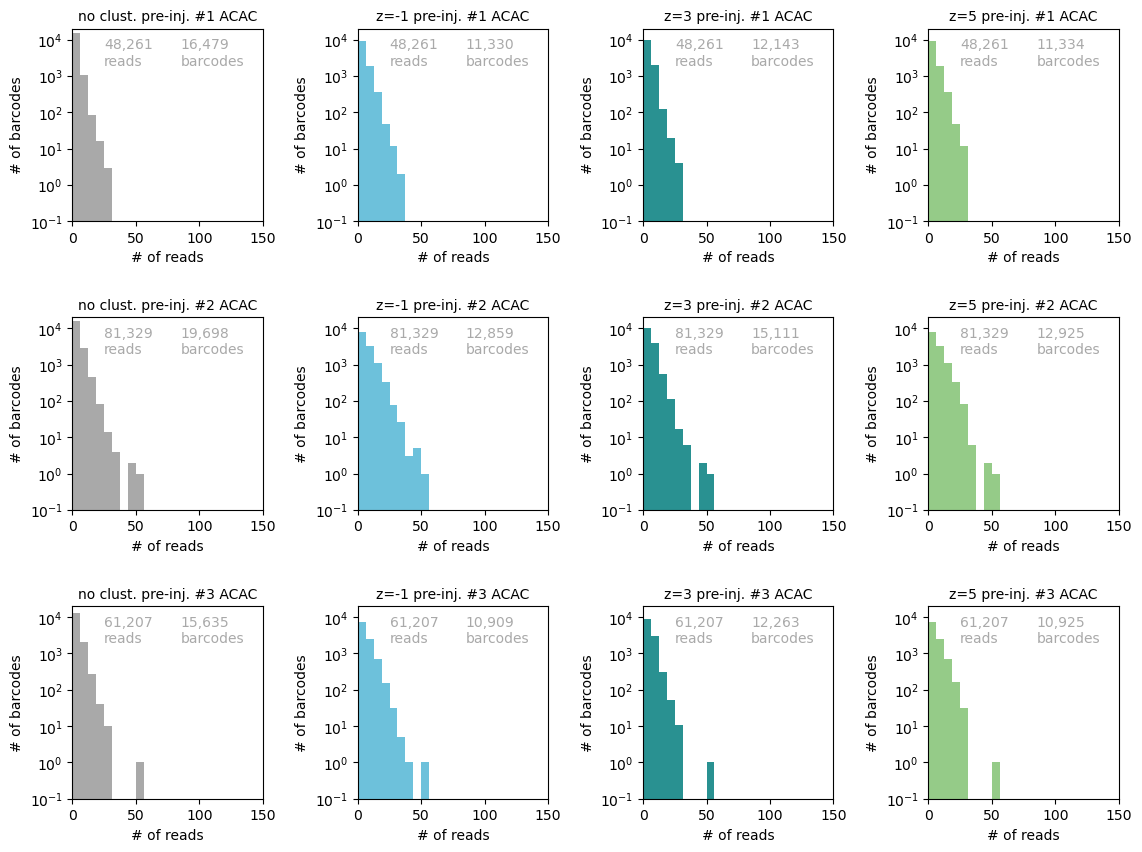

In [7]:
colors = ['#6DC1DB', '#299191', '#95CB88']

plt.figure(figsize=(3 * 4 + 1.5, 3 * 3 + 1))

grid = gridspec.GridSpec(ncols=4, nrows=3,
                         width_ratios=[1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

ind = 2 # clID index

for i in range(12):
    
    plt.subplot(grid[i // 4, i % 4])
        
    if i % 4 == 0: # pre-clustering
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9')
                #total_n_reads = sum([sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][x]) for x in pre_inj_pre_clust_clID_count['SK1_61'].keys() if x != 'GATC'])
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('no clust. pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)
                
                
    if i % 4 == 1: # z=-1
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                plt.hist(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[0])
                #total_n_reads = sum([sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][x]) for x in pre_inj_pre_clust_clID_count['SK1_61'].keys() if x != 'GATC'])
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=-1 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 2: # z=3
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                plt.hist(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[1])
                #total_n_reads = sum([sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][x]) for x in pre_inj_pre_clust_clID_count['SK1_61'].keys() if x != 'GATC'])
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=3 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 3: # z=5
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                plt.hist(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[2])
                #total_n_reads = sum([sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][x]) for x in pre_inj_pre_clust_clID_count['SK1_61'].keys() if x != 'GATC'])
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=5 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

        
#plt.savefig('plots/pre-inj_bc_distr_comparison_' + clIDs[ind] + '.png', dpi=600, bbox_inches='tight') 


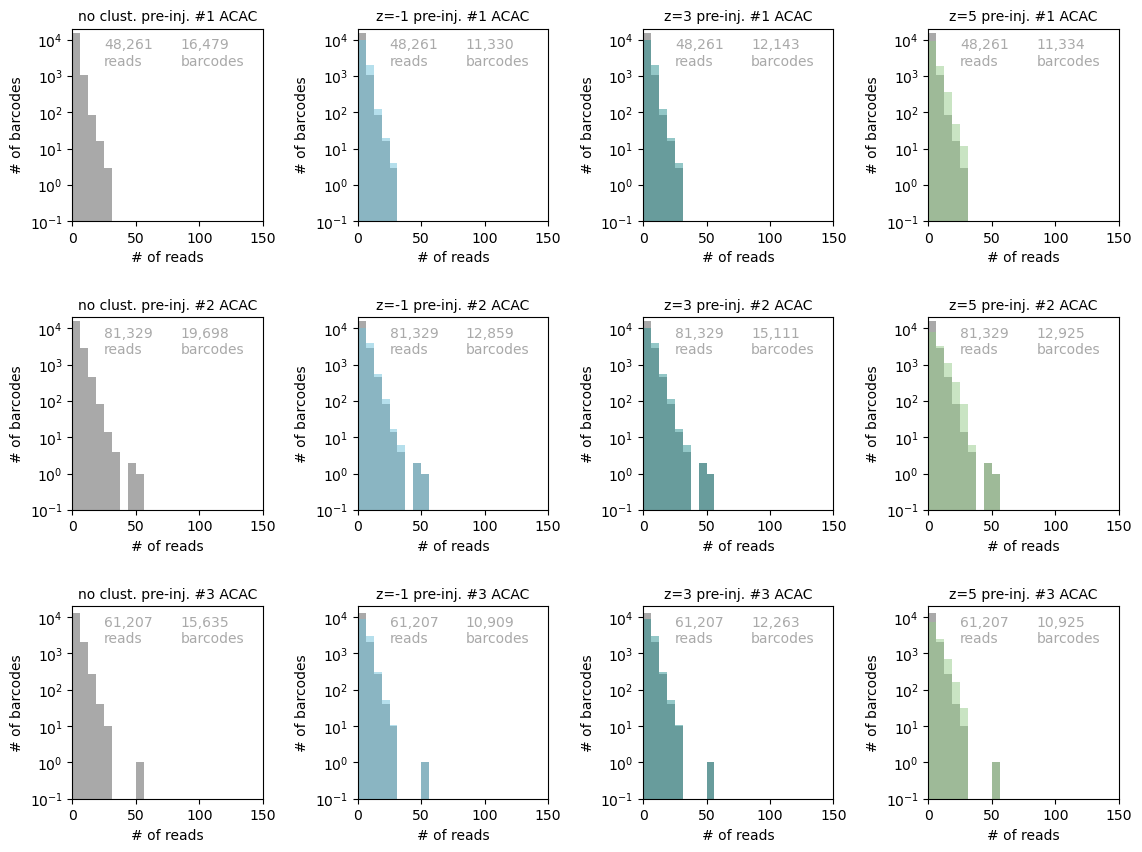

In [8]:
colors = ['#6DC1DB', '#299191', '#95CB88']

plt.figure(figsize=(3 * 4 + 1.5, 3 * 3 + 1))

grid = gridspec.GridSpec(ncols=4, nrows=3,
                         width_ratios=[1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

ind = 2 # clID index

for i in range(12):
    
    plt.subplot(grid[i // 4, i % 4])
        
    if i % 4 == 0: # pre-clustering
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('no clust. pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)
                
                
    if i % 4 == 1: # z=-1
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                plt.hist(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[0], alpha=0.5)
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=-1 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 2: # z=3
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                plt.hist(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[1], alpha=0.5)
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=3 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 3: # z=5
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                plt.hist(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[2], alpha=0.5)

                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=5 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

        
#plt.savefig('plots/pre-inj_bc_distr_comparison_' + clIDs[ind] + '_overlayed.png', dpi=600, bbox_inches='tight') 


In [ ]:
def hamming(x, y):
    return sum(i != j for i, j in zip(x, y))

In [22]:
i = 2
for j in range(len(samples_pre_inj)):
    pre_clust_bc_list = np.array(list(pre_inj_pre_clust_clID_bc_count[samples_pre_inj[j]][clIDs[i]].keys()))
    z1_clust_bc_list = np.array(pre_inj_z1_clust_clID_bc[samples_pre_inj[j]][clIDs[i]])
    z3_clust_bc_list = np.array(pre_inj_z3_clust_clID_bc[samples_pre_inj[j]][clIDs[i]])
    z5_clust_bc_list = np.array(pre_inj_z5_clust_clID_bc[samples_pre_inj[j]][clIDs[i]])
    
    np.save(f"pre_clust_bc_list_{samples_pre_inj[j]}_{clIDs[i]}.npy", pre_clust_bc_list)
    np.save(f"z=-1_clust_bc_list_{samples_pre_inj[j]}_{clIDs[i]}.npy", z1_clust_bc_list)
    np.save(f"z=3_clust_bc_list_{samples_pre_inj[j]}_{clIDs[i]}.npy", z3_clust_bc_list)
    np.save(f"z=5_clust_bc_list_{samples_pre_inj[j]}_{clIDs[i]}.npy", z5_clust_bc_list)

In [31]:
pre_clust_hammings = {}
z1_clust_hammings = {}
z3_clust_hammings = {}
z5_clust_hammings = {}
i = 2
for j in range(len(samples_pre_inj)):
    
    with open(f"output/pre_clust_hamming_d_disr_{samples_pre_inj[j]}_{clIDs[i]}.txt") as f:
        lines = f.readlines()
    pre_clust_hammings[samples_pre_inj[j]] = [[int(x.strip('\n').split(':')[0]), int(x.strip('\n').split(':')[1])] for x in lines]

    with open(f"output/z=-1_clust_hamming_d_disr_{samples_pre_inj[j]}_{clIDs[i]}.txt") as f:
        lines = f.readlines()
    z1_clust_hammings[samples_pre_inj[j]] = [[int(x.strip('\n').split(':')[0]), int(x.strip('\n').split(':')[1])] for x in lines]

    with open(f"output/z=3_clust_hamming_d_disr_{samples_pre_inj[j]}_{clIDs[i]}.txt") as f:
        lines = f.readlines()
    z3_clust_hammings[samples_pre_inj[j]] = [[int(x.strip('\n').split(':')[0]), int(x.strip('\n').split(':')[1])] for x in lines]

    with open(f"output/z=5_clust_hamming_d_disr_{samples_pre_inj[j]}_{clIDs[i]}.txt") as f:
        lines = f.readlines()
    z5_clust_hammings[samples_pre_inj[j]] = [[int(x.strip('\n').split(':')[0]), int(x.strip('\n').split(':')[1])] for x in lines]


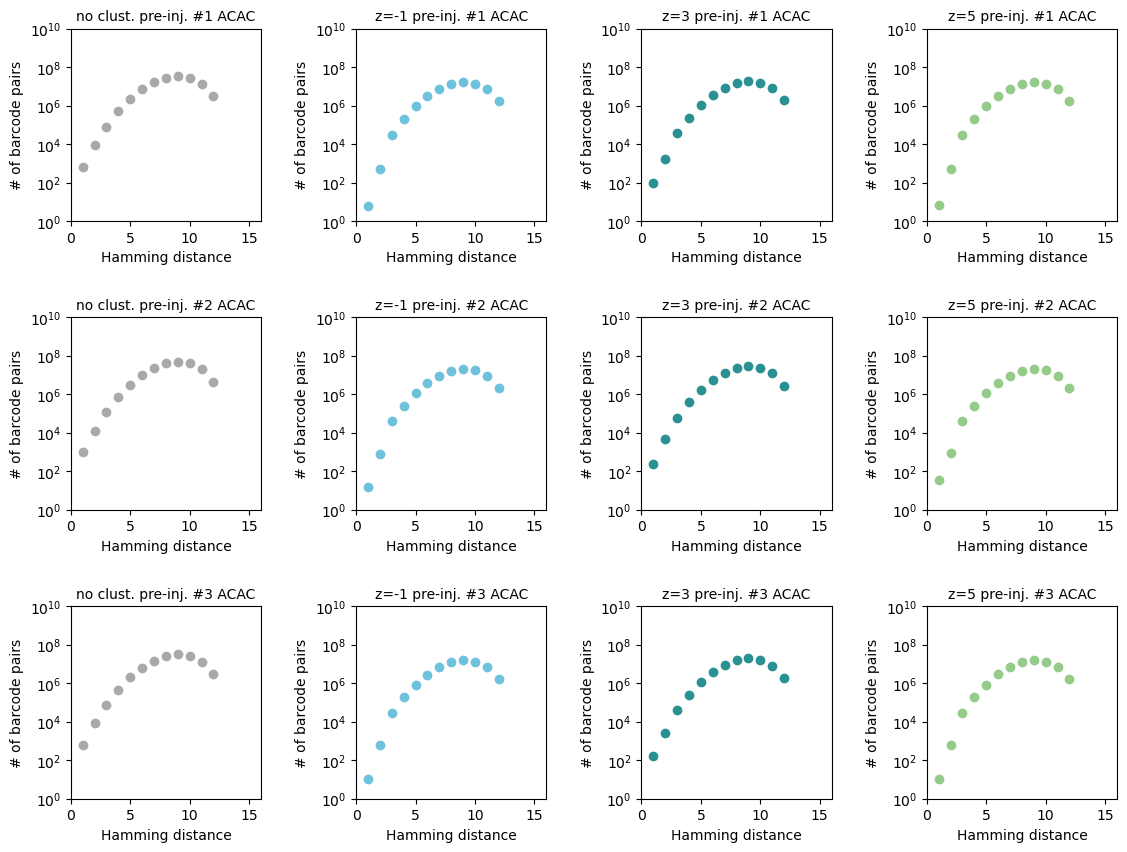

In [47]:
colors = ['#6DC1DB', '#299191', '#95CB88']

plt.figure(figsize=(3 * 4 + 1.5, 3 * 3 + 1))

grid = gridspec.GridSpec(ncols=4, nrows=3,
                         width_ratios=[1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

ind = 2 # clID index

for i in range(12):
    
    plt.subplot(grid[i // 4, i % 4])
        
    if i % 4 == 0: # pre-clustering
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                  
                plt.scatter([x[0] for x in pre_clust_hammings[samples_pre_inj[j]]], [x[1] for x in pre_clust_hammings[samples_pre_inj[j]]], color='#a9a9a9')                
                            
                #plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                #plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 16); plt.ylim(1e0, 1e10)
            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('no clust. pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)
                
                
    if i % 4 == 1: # z=-1
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.scatter([x[0] for x in z1_clust_hammings[samples_pre_inj[j]]], [x[1] for x in z1_clust_hammings[samples_pre_inj[j]]], color=colors[0])                
            
                #plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                #plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 16); plt.ylim(1e0, 1e10)
                
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('z=-1 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 2: # z=3
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.scatter([x[0] for x in z3_clust_hammings[samples_pre_inj[j]]], [x[1] for x in z3_clust_hammings[samples_pre_inj[j]]], color=colors[1])                
            
                #plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                #plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 16); plt.ylim(1e0, 1e10)
                            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('z=3 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 3: # z=5
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.scatter([x[0] for x in z5_clust_hammings[samples_pre_inj[j]]], [x[1] for x in z5_clust_hammings[samples_pre_inj[j]]], color=colors[2])                
            
                #plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                #plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 16); plt.ylim(1e0, 1e10)
                            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('z=5 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

        
#plt.savefig('plots/pre-inj_hamming_d_comparison_' + clIDs[ind] + '.png', dpi=600, bbox_inches='tight') 


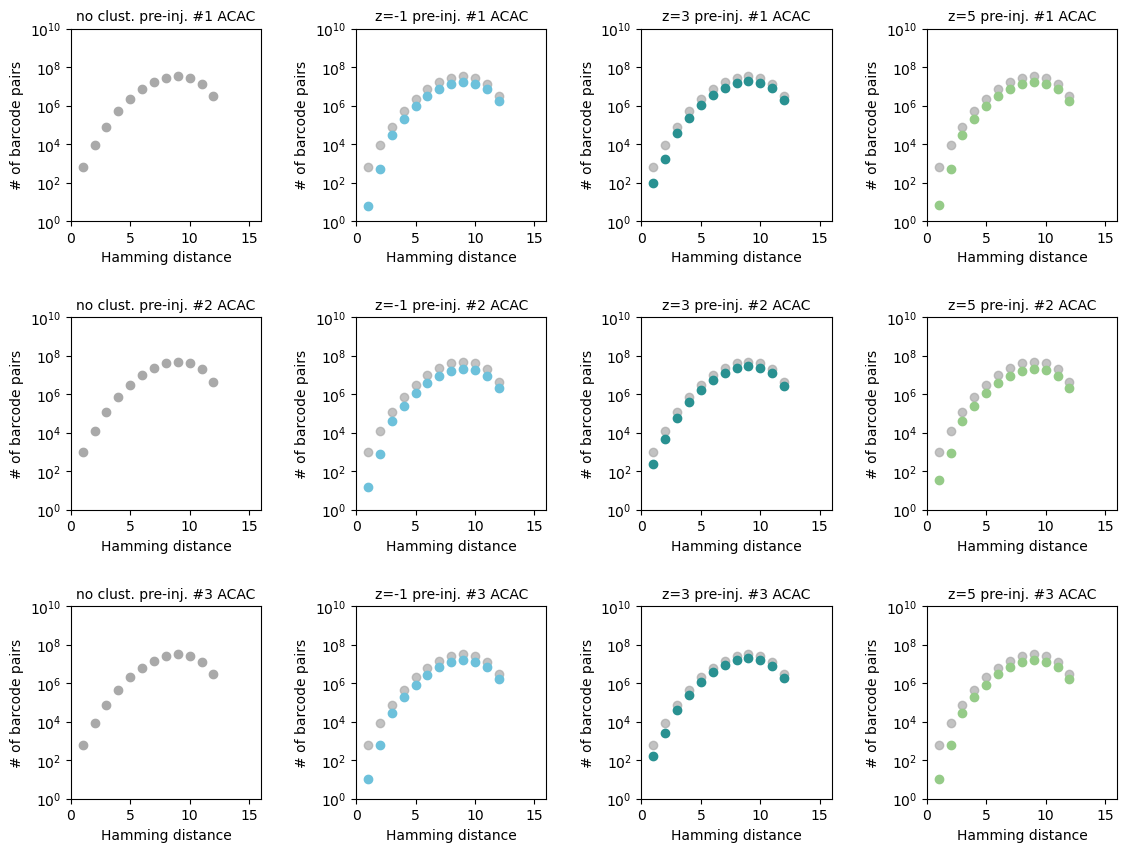

In [48]:
colors = ['#6DC1DB', '#299191', '#95CB88']

plt.figure(figsize=(3 * 4 + 1.5, 3 * 3 + 1))

grid = gridspec.GridSpec(ncols=4, nrows=3,
                         width_ratios=[1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

ind = 2 # clID index

for i in range(12):
    
    plt.subplot(grid[i // 4, i % 4])
        
    if i % 4 == 0: # pre-clustering
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                  
                plt.scatter([x[0] for x in pre_clust_hammings[samples_pre_inj[j]]], [x[1] for x in pre_clust_hammings[samples_pre_inj[j]]], color='#a9a9a9')                
                            
                #plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                #plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 16); plt.ylim(1e0, 1e10)
            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('no clust. pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)
                
                
    if i % 4 == 1: # z=-1
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.scatter([x[0] for x in pre_clust_hammings[samples_pre_inj[j]]], [x[1] for x in pre_clust_hammings[samples_pre_inj[j]]], color='#a9a9a9', alpha=0.7)                
                plt.scatter([x[0] for x in z1_clust_hammings[samples_pre_inj[j]]], [x[1] for x in z1_clust_hammings[samples_pre_inj[j]]], color=colors[0])                
            
                #plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                #plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 16); plt.ylim(1e0, 1e10)
                
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('z=-1 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 2: # z=3
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.scatter([x[0] for x in pre_clust_hammings[samples_pre_inj[j]]], [x[1] for x in pre_clust_hammings[samples_pre_inj[j]]], color='#a9a9a9', alpha=0.7)                
                plt.scatter([x[0] for x in z3_clust_hammings[samples_pre_inj[j]]], [x[1] for x in z3_clust_hammings[samples_pre_inj[j]]], color=colors[1])                
            
                #plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                #plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 16); plt.ylim(1e0, 1e10)
                            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('z=3 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 3: # z=5
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.scatter([x[0] for x in pre_clust_hammings[samples_pre_inj[j]]], [x[1] for x in pre_clust_hammings[samples_pre_inj[j]]], color='#a9a9a9', alpha=0.7)                
                plt.scatter([x[0] for x in z5_clust_hammings[samples_pre_inj[j]]], [x[1] for x in z5_clust_hammings[samples_pre_inj[j]]], color=colors[2])                
            
                #plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                #plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 16); plt.ylim(1e0, 1e10)
                            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('z=5 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

        
#plt.savefig('plots/pre-inj_hamming_d_comparison_' + clIDs[ind] + '_overlayed.png', dpi=600, bbox_inches='tight') 


In [184]:
! ls output/*small*
! head output/pre_clust_small_d_bc_SK1_61_ACAC.txt

output/pre_clust_small_d_bc_SK1_61_ACAC.txt
output/pre_clust_small_d_bc_SK1_62_ACAC.txt
output/pre_clust_small_d_bc_SK1_63_ACAC.txt
output/z=-1_clust_small_d_bc_SK1_61_ACAC.txt
output/z=-1_clust_small_d_bc_SK1_62_ACAC.txt
output/z=-1_clust_small_d_bc_SK1_63_ACAC.txt
output/z=3_clust_small_d_bc_SK1_61_ACAC.txt
output/z=3_clust_small_d_bc_SK1_62_ACAC.txt
output/z=3_clust_small_d_bc_SK1_63_ACAC.txt
output/z=5_clust_small_d_bc_SK1_61_ACAC.txt
output/z=5_clust_small_d_bc_SK1_62_ACAC.txt
output/z=5_clust_small_d_bc_SK1_63_ACAC.txt
TGTGACTGGGGGGCGG TGTGTCTGGGGGGAGG2
TGTGACTGGGGGGCGG TGTGAATGTGGGGCGG2
TGTGACTGGGGGGCGG TGTGACTGGAGGGCAG2
TGTGACTGGGGGGCGG TGTGACTGTTGGGCGG2
CCGGTCCGGACGGGCG CCGGCCCGGACGGGCG1
CCGGTCCGGACGGGCG CCTGTGCGGACGGGCG2
CTGGGCAGAGGGGGCG TTGGGCAGGGGGGGCG2
CTGGGCAGAGGGGGCG TTGGGCAGAGTGGGCG2
AATGTCTGAAGGACGG ATTGTCTGAATGACGG2
TATGCGGGGCAGGGAG TATGCAGGGCAGGGTG2


In [208]:
pre_clust_small_d_size_ratios = {}
z1_clust_small_d_size_ratios = {}
z3_clust_small_d_size_ratios = {}
z5_clust_small_d_size_ratios = {}
i = 2
for j in range(len(samples_pre_inj)):
    
    with open(f"output/pre_clust_small_d_bc_{samples_pre_inj[j]}_{clIDs[i]}.txt") as f:
        barcodes = [[x.split()[0], x.split()[-1][:-1]] for x in f.readlines()]
        
    sizes = [[pre_inj_pre_clust_clID_bc_count[samples_pre_inj[j]][clIDs[i]].get(x[0]), pre_inj_pre_clust_clID_bc_count[samples_pre_inj[j]][clIDs[i]].get(x[1])] for x in barcodes]
    ratios = [min(x) / max(x) for x in sizes]
    
    pre_clust_small_d_size_ratios[samples_pre_inj[j]] = ratios
    
    
    with open(f"output/z=-1_clust_small_d_bc_{samples_pre_inj[j]}_{clIDs[i]}.txt") as f:
        barcodes = [[x.split()[0], x.split()[-1][:-1]] for x in f.readlines()]
        
    sizes = [[pre_inj_z1_clust_clID_bc_count[samples_pre_inj[j]][clIDs[i]].get(x[0]), pre_inj_z1_clust_clID_bc_count[samples_pre_inj[j]][clIDs[i]].get(x[1])] for x in barcodes]
    ratios = [min(x) / max(x) for x in sizes]
    
    z1_clust_small_d_size_ratios[samples_pre_inj[j]] = ratios
    
    
    with open(f"output/z=3_clust_small_d_bc_{samples_pre_inj[j]}_{clIDs[i]}.txt") as f:
        barcodes = [[x.split()[0], x.split()[-1][:-1]] for x in f.readlines()]
        
    sizes = [[pre_inj_z3_clust_clID_bc_count[samples_pre_inj[j]][clIDs[i]].get(x[0]), pre_inj_z3_clust_clID_bc_count[samples_pre_inj[j]][clIDs[i]].get(x[1])] for x in barcodes]
    ratios = [min(x) / max(x) for x in sizes]
    
    z3_clust_small_d_size_ratios[samples_pre_inj[j]] = ratios
    
    
    with open(f"output/z=5_clust_small_d_bc_{samples_pre_inj[j]}_{clIDs[i]}.txt") as f:
        barcodes = [[x.split()[0], x.split()[-1][:-1]] for x in f.readlines()]
        
    sizes = [[pre_inj_z5_clust_clID_bc_count[samples_pre_inj[j]][clIDs[i]].get(x[0]), pre_inj_z5_clust_clID_bc_count[samples_pre_inj[j]][clIDs[i]].get(x[1])] for x in barcodes]
    ratios = [min(x) / max(x) for x in sizes]
    
    z5_clust_small_d_size_ratios[samples_pre_inj[j]] = ratios

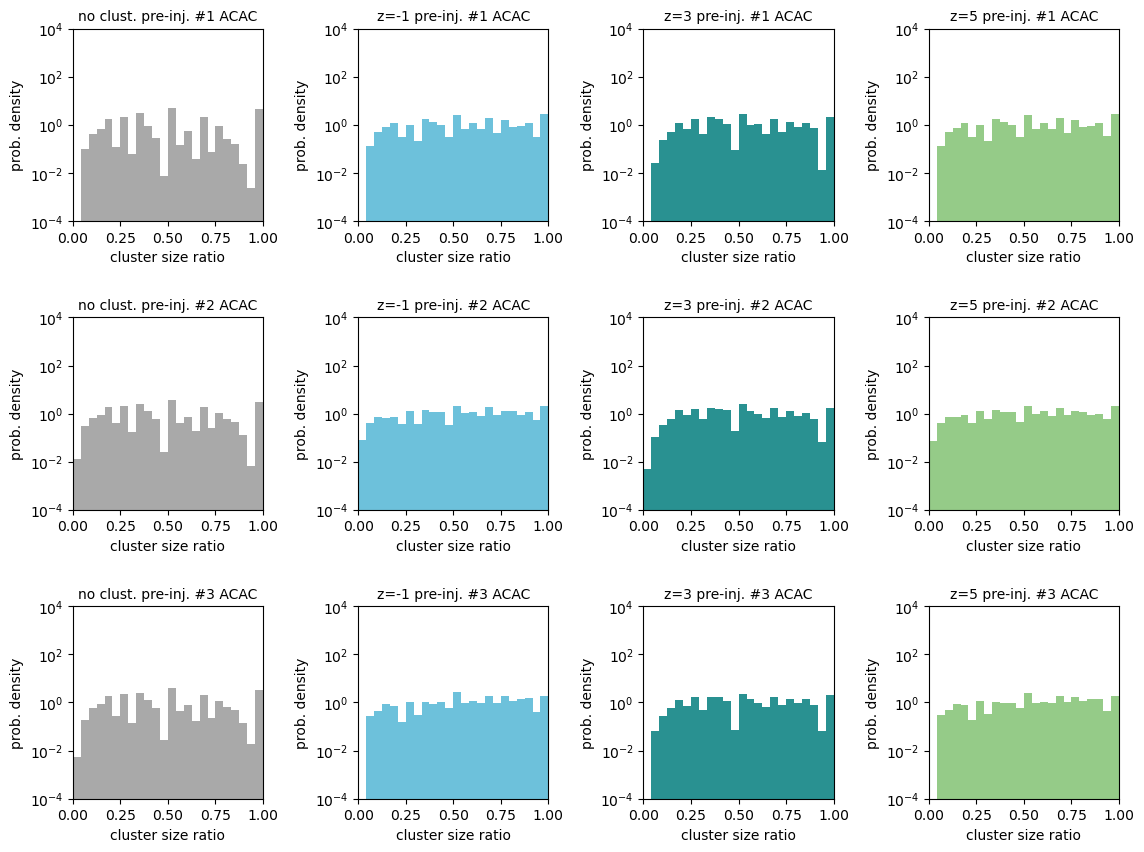

In [222]:
colors = ['#6DC1DB', '#299191', '#95CB88']

plt.figure(figsize=(3 * 4 + 1.5, 3 * 3 + 1))

grid = gridspec.GridSpec(ncols=4, nrows=3,
                         width_ratios=[1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

ind = 2 # clID index

for i in range(12):
    
    plt.subplot(grid[i // 4, i % 4])
        
    if i % 4 == 0: # pre-clustering
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                
                plt.hist(pre_clust_small_d_size_ratios[samples_pre_inj[j]], bins=np.linspace(0,1,25), color='#a9a9a9', alpha=1, density=True)
 
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 1); plt.ylim(1e-4, 1e4)
            
                plt.ylabel('prob. density', fontsize=10);
                plt.xlabel('cluster size ratio', fontsize=10);
                plt.title('no clust. pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)
                
                
    if i % 4 == 1: # z=-1
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                
                plt.hist(z1_clust_small_d_size_ratios[samples_pre_inj[j]], bins=np.linspace(0,1,25), color=colors[0], alpha=1, density=True)

                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 1); plt.ylim(1e-4, 1e4)
                
                plt.ylabel('prob. density', fontsize=10);
                plt.xlabel('cluster size ratio', fontsize=10);
                plt.title('z=-1 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 2: # z=3
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                
                plt.hist(z3_clust_small_d_size_ratios[samples_pre_inj[j]], bins=np.linspace(0,1,25), color=colors[1], alpha=1, density=True)
                
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 1); plt.ylim(1e-4, 1e4)
                            
                plt.ylabel('prob. density', fontsize=10);
                plt.xlabel('cluster size ratio', fontsize=10);
                plt.title('z=3 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 3: # z=5
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
               
                plt.hist(z5_clust_small_d_size_ratios[samples_pre_inj[j]], bins=np.linspace(0,1,25), color=colors[2], alpha=1, density=True)
                
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 1); plt.ylim(1e-4, 1e4)
                            
                plt.ylabel('prob. density', fontsize=10);
                plt.xlabel('cluster size ratio', fontsize=10);
                plt.title('z=5 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

        
#plt.savefig('plots/pre-inj_small_hamming_d_sizes_ratio_' + clIDs[ind] + '.png', dpi=600, bbox_inches='tight') 


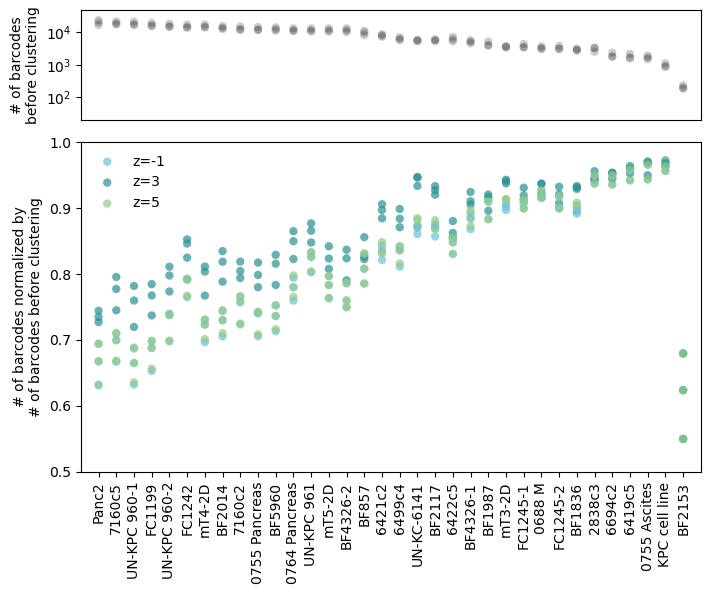

In [21]:
colors = ['#6DC1DB', '#299191', '#95CB88']
ind = [7, 4, 14, 2, 24, 33, 0, 17, 1, 15, 18, 29, 34, 28, 13, 5, 30, 19, 26, 11, 20, 10, 6, 27, 9, 8, 21, 16, 32, 3, 12, 31, 22, 25]

plt.figure(figsize=(8, 6))

grid = gridspec.GridSpec(ncols=1, nrows=2,
                         width_ratios=[1], wspace=0.2,
                         height_ratios=[1, 3], hspace=0.1)


plt.subplot(grid[0 // 1, 0 % 1])

for i in range(len(ind)):
    for j in range(len(samples_pre_inj)):   
        #if j !=2:
        #    continue
            
        plt.scatter(i, len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]), facecolors='black', edgecolors='none', alpha=0.2)

plt.yscale('log'); plt.minorticks_off()
plt.ylim(2e1, 5e4)

plt.xlim(-1, 34);
plt.xticks([], []);

plt.ylabel('# of barcodes\nbefore clustering', fontsize=10);




plt.subplot(grid[1 // 1, 1 % 1])

for i in range(len(ind)):
    for j in range(len(samples_pre_inj)):   
        
        if i == 0 and j == 0:
            labels = ['z=-1', 'z=3', 'z=5']
        else:
            labels = ['', '', '']
        
        plt.scatter(i, len(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]) / len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]), facecolors=colors[0], edgecolors='none', alpha=0.7, label=labels[0])
        plt.scatter(i, len(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]) / len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]), facecolors=colors[1], edgecolors='none', alpha=0.7, label=labels[1])
        plt.scatter(i, len(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]) / len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]), facecolors=colors[2], edgecolors='none', alpha=0.7, label=labels[2])

plt.ylim(0.5, 1);
plt.xticks(range(len(ind)), [clID_dict[clIDs[ind[i]]].replace('_', ' ') for i in range(len(ind))], rotation=90);
plt.xlim(-1, 34);

plt.ylabel('# of barcodes normalized by\n# of barcodes before clustering', fontsize=10);

plt.legend(frameon=False, fontsize=10, loc='upper left', ncol=1);




#plt.savefig('plots/bc_loss_comparison.png', dpi=600, bbox_inches='tight') 

In [62]:
t_series_samples = {} # with reps as keys and sample names as values

for j in range(len(samples_pre_inj)):
    t_series_samples[j] = [samples_pre_inj[j]]
    
for i in range(len(samples_in_vitro)):
    for j in range(len(samples_pre_inj)):
        if (int(samples_in_vitro[i].split('_')[-1]) - int(samples_pre_inj[j].split('_')[-1])) % 3 == 0:
            t_series_samples[j].append(samples_in_vitro[i])


In [81]:
# a list of barcodes seen in a replicate for each cell line
t_bc_list = {}
for rep in range(len(samples_pre_inj)):
    t_bc_list[rep] = {} # initializing a dict for each replicate 
    
    for sample in t_series_samples[rep]: 
        for line in open(f"output/z=5/{sample}_merged_clIDs_bc_clusters_counts.txt", 'r'):
        
            clID, bc = line.strip('\n').split()[0].split('_')
            # count = int(line.strip('\n').split()[-1])
            
            if clID not in t_bc_list[rep]:
                t_bc_list[rep][clID] = set() # initializing a set for each cell line
                
            t_bc_list[rep][clID].add(bc) # adding a barcode to the set 
            

In [94]:
# now tracking all these barcodes
t_bc_counts = {}
for rep in range(len(samples_pre_inj)):
    t_bc_counts[rep] = {} # initializing a dict for each replicate 
                        
    for clID in t_bc_list[rep].keys():
        t_bc_counts[rep][clID] = dict(zip(t_bc_list[rep][clID], np.zeros((len(t_bc_list[rep][clID]), len(t_series_samples[rep])), dtype=int))) # initializing a dict for each cell line
                                                                                                                                                   # with barcodes as keys and lists of counts across t as values
    for t in range(len(t_series_samples[rep])): 
        for line in open(f"output/z=5/{t_series_samples[rep][t]}_merged_clIDs_bc_clusters_counts.txt", 'r'):
            clID, bc = line.strip('\n').split()[0].split('_')
            count = int(line.strip('\n').split()[-1])
            
            t_bc_counts[rep][clID][bc][t] += count

In [115]:
# calculating total coverage at each time point:
t_series_coverage = {}

for rep in range(len(samples_pre_inj)):
    t_series_coverage[rep] = {} # initializing a dict for each replicate 
    
    for sample in t_series_samples[rep]:
        c = 0
        for line in open(f"output/z=5/{sample}_merged_clIDs_bc_clusters_counts.txt", 'r'):
            if line.strip('\n').split()[0].split('_')[0] != 'GATC': # EXCLUDING SPIKE-INS
                c += int(line.strip('\n').split()[-1])
        t_series_coverage[rep][sample] = c


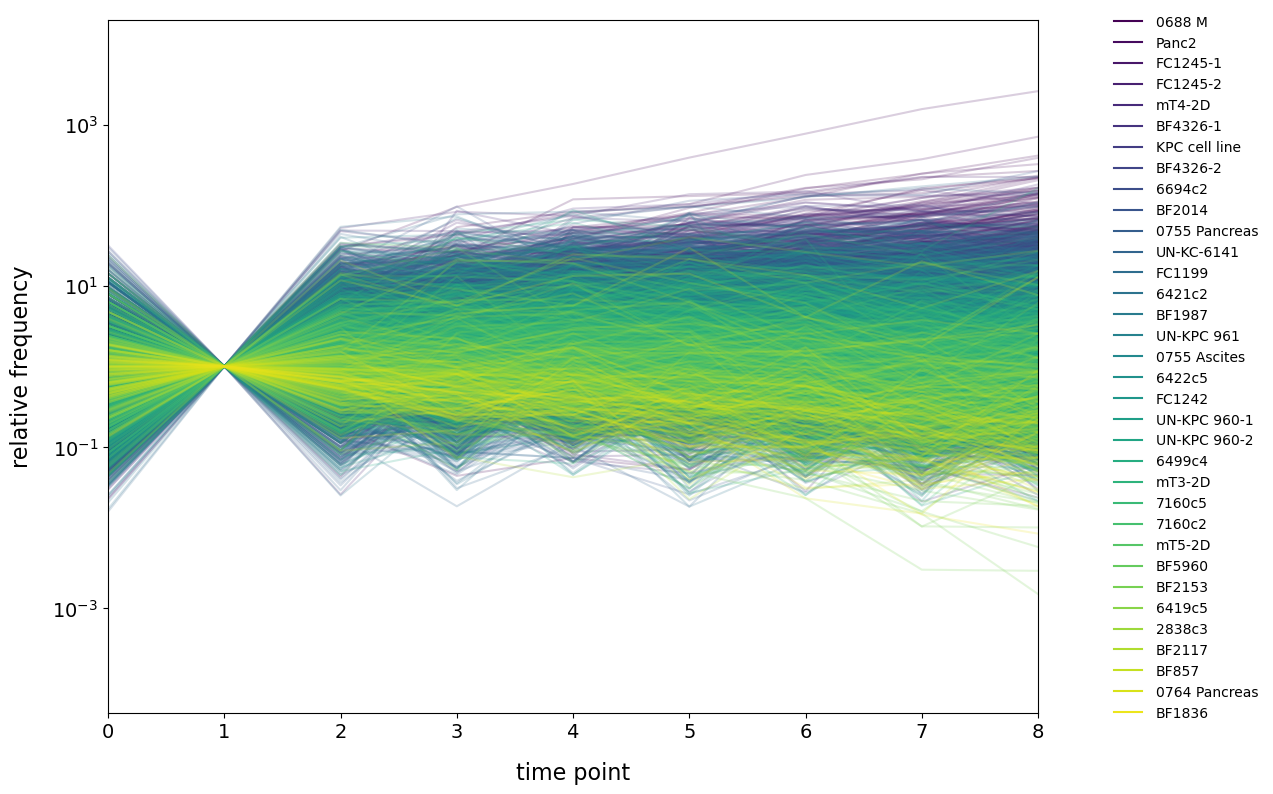

In [166]:
plt.figure(figsize=(12, 9));
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))
rep = 0
for count, clID in enumerate(clIDs_ordered):
    for x in t_bc_counts[rep][clID].keys():
        if 0 not in t_bc_counts[rep][clID][x]:
            plt.plot(range(0, 9), [t_bc_counts[rep][clID][x][i] / t_series_coverage[rep][t_series_samples[rep][i]] / (t_bc_counts[rep][clID][x][1] / t_series_coverage[rep][t_series_samples[rep][1]]) for i in range(0, 9)], color=viridis.to_rgba(count), alpha=0.2)
        
    plt.plot([10, 10], [1, 1], color=viridis.to_rgba(count), label=clID_dict[clID].replace('_', ' '))
    
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], size=14)
plt.xlim(0, 8)

plt.yticks([1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], [1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], size=14)
plt.yscale('log'); plt.minorticks_off();
plt.ylim(5e-5, 2e4)

plt.xlabel('time point', fontsize=16, labelpad=14);
plt.ylabel('relative frequency', fontsize=16, labelpad=14);

# plt.title('in vitro', size=16, pad=14)
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.025)); 


#plt.savefig('plots/bc_rep_1.png', dpi=600, bbox_inches='tight')     
    

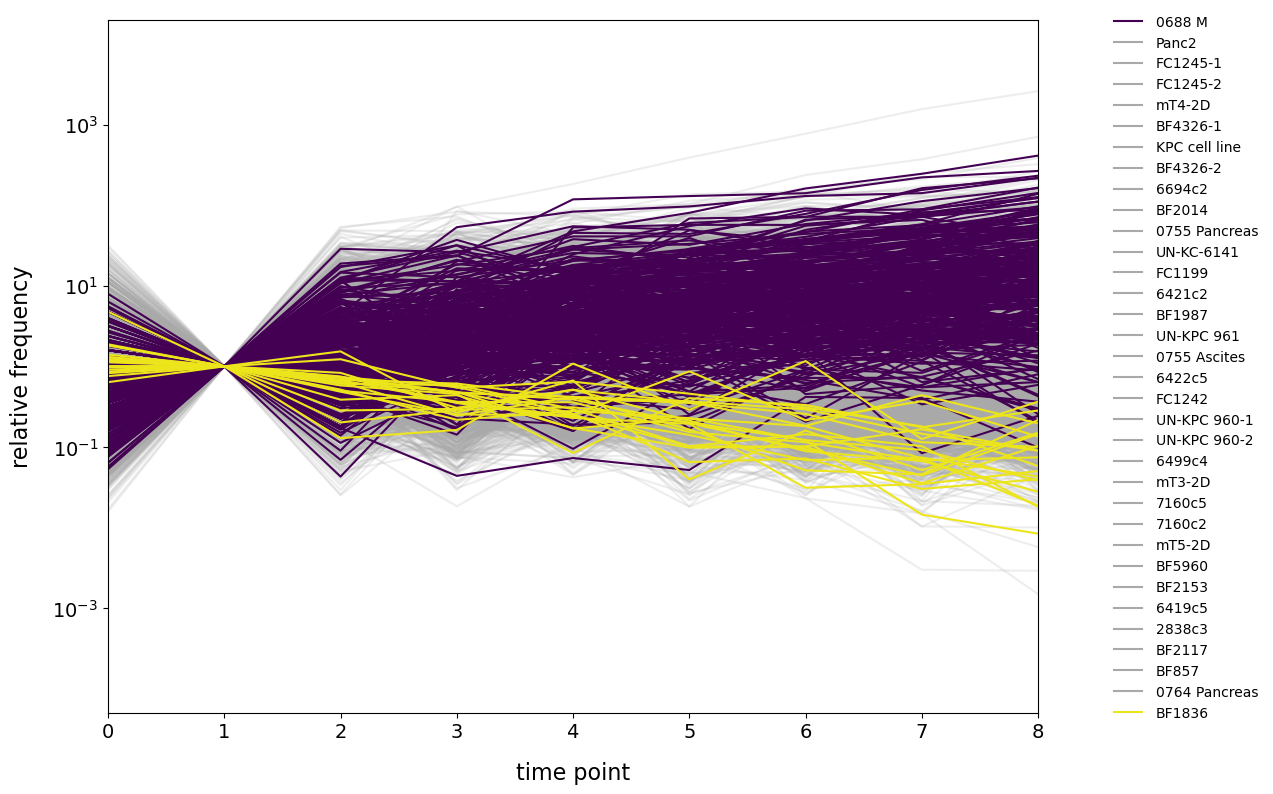

In [170]:
plt.figure(figsize=(12, 9));
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))
rep = 0
for count, clID in enumerate(clIDs_ordered):
    if clID in [clIDs_ordered[0], clIDs_ordered[-1]]:
        continue
        
    for x in t_bc_counts[rep][clID].keys():
        if 0 not in t_bc_counts[rep][clID][x]:
            plt.plot(range(0, 9), [t_bc_counts[rep][clID][x][i] / t_series_coverage[rep][t_series_samples[rep][i]] / (t_bc_counts[rep][clID][x][1] / t_series_coverage[rep][t_series_samples[rep][1]]) for i in range(0, 9)], color='#a9a9a9', alpha=0.2)

for count, clID in enumerate(clIDs_ordered):
    if clID not in [clIDs_ordered[0], clIDs_ordered[-1]]:
        continue
        
    for x in t_bc_counts[rep][clID].keys():
        if 0 not in t_bc_counts[rep][clID][x]:
            plt.plot(range(0, 9), [t_bc_counts[rep][clID][x][i] / t_series_coverage[rep][t_series_samples[rep][i]] / (t_bc_counts[rep][clID][x][1] / t_series_coverage[rep][t_series_samples[rep][1]]) for i in range(0, 9)], color=viridis.to_rgba(count), alpha=1)
            
            
for count, clID in enumerate(clIDs_ordered):
    if clID not in [clIDs_ordered[0], clIDs_ordered[-1]]:
        c = '#a9a9a9'
    else: 
        c = viridis.to_rgba(count)
    plt.plot([10, 10], [1, 1], color=c, label=clID_dict[clID].replace('_', ' '))
    
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], size=14)
plt.xlim(0, 8)

plt.yticks([1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], [1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], size=14)
plt.yscale('log'); plt.minorticks_off();
plt.ylim(5e-5, 2e4)

plt.xlabel('time point', fontsize=16, labelpad=14);
plt.ylabel('relative frequency', fontsize=16, labelpad=14);

# plt.title('in vitro', size=16, pad=14)
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.025)); 


#plt.savefig('plots/bc_rep_1_high_low.png', dpi=600, bbox_inches='tight')     
    

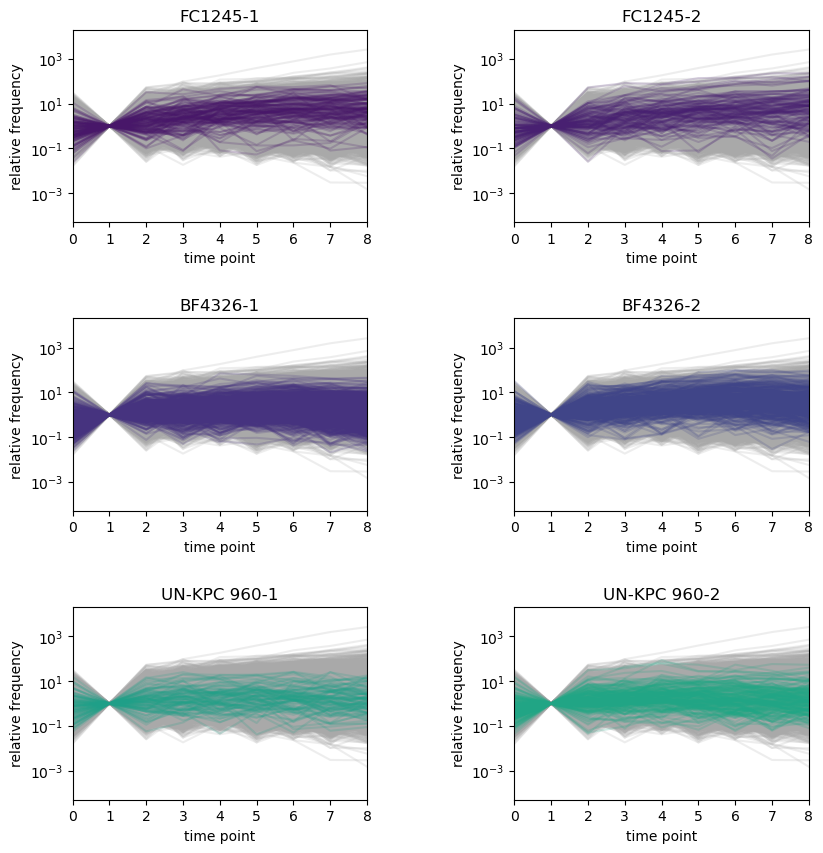

In [181]:
plt.figure(figsize=(4 * 2 + 1.5, 3 * 3 + 1))

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))

grid = gridspec.GridSpec(ncols=2, nrows=3,
                         width_ratios=[1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

reps = ['FC1245-1', 'FC1245-2', 'BF4326-1', 'BF4326-2', 'UN-KPC_960-1', 'UN-KPC_960-2']
ids = [cell_lines_ordered.index(i) for i in reps]

for i in range(6):
    
    plt.subplot(grid[i // 2, i % 2])
    
    clID = cell_line_dict[reps[i]]
    rep = 0
    
        
    for count, y in enumerate(clIDs_ordered):
        if y == clID:
            continue
        
        for x in t_bc_counts[rep][y].keys():
            if 0 not in t_bc_counts[rep][y][x]:
                plt.plot(range(0, 9), [t_bc_counts[rep][y][x][i] / t_series_coverage[rep][t_series_samples[rep][i]] / (t_bc_counts[rep][y][x][1] / t_series_coverage[rep][t_series_samples[rep][1]]) for i in range(0, 9)], color='#a9a9a9', alpha=0.2)

    for x in t_bc_counts[rep][clID].keys():
        if 0 not in t_bc_counts[rep][clID][x]:
            plt.plot(range(0, 9), [t_bc_counts[rep][clID][x][i] / t_series_coverage[rep][t_series_samples[rep][i]] / (t_bc_counts[rep][clID][x][1] / t_series_coverage[rep][t_series_samples[rep][1]]) for i in range(0, 9)], color=viridis.to_rgba(ids[i]), alpha=0.2)

    
    plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], size=10)
    plt.xlim(0, 8)

    plt.yticks([1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], [1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], size=10)
    plt.yscale('log'); plt.minorticks_off();
    plt.ylim(5e-5, 2e4)
    
    plt.title(reps[i].replace('_', ' '))
    plt.xlabel('time point', fontsize=10);
    plt.ylabel('relative frequency', fontsize=10);
    
#plt.savefig('plots/bc_rep_1_reps.png', dpi=600, bbox_inches='tight')  

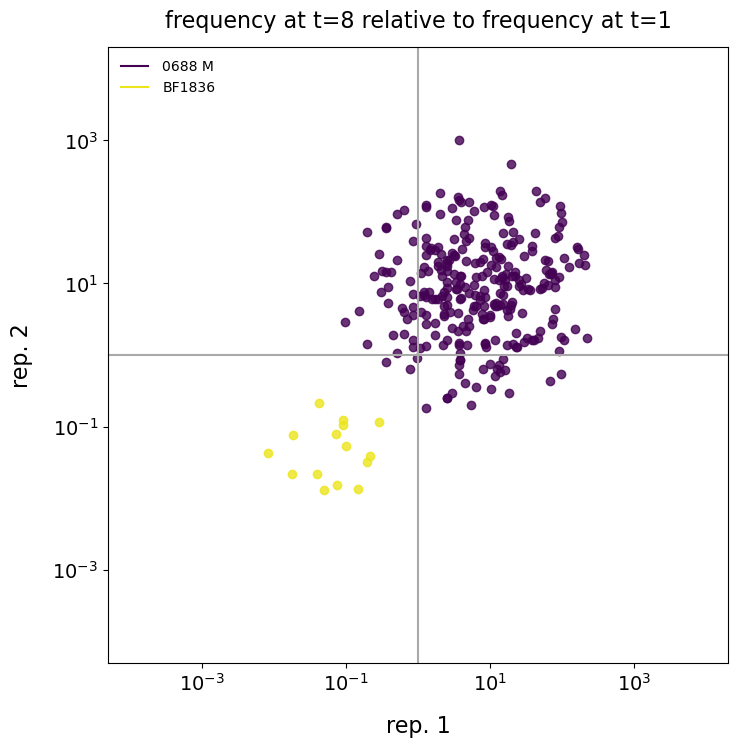

In [289]:
# want to look at correlations, starting at t=0
# getting a set of barcodes that are present in both replicates 

plt.figure(figsize=(8, 8));
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))
reps = [0, 1]
coverage_rep1_t8 = t_series_coverage[reps[0]][t_series_samples[reps[0]][-1]]
coverage_rep2_t8 = t_series_coverage[reps[1]][t_series_samples[reps[1]][-1]]
coverage_rep1_t1 = t_series_coverage[reps[0]][t_series_samples[reps[0]][1]]
coverage_rep2_t1 = t_series_coverage[reps[1]][t_series_samples[reps[1]][1]]
for count, clID in enumerate(clIDs_ordered):
    if clID not in [clIDs_ordered[0], clIDs_ordered[-1]]:
        continue
    barcodes = list(t_bc_counts[reps[0]][clID].keys() & t_bc_counts[reps[1]][clID].keys())
    for x in barcodes:
        if 0 not in [t_bc_counts[reps[0]][clID][x][1], t_bc_counts[reps[1]][clID][x][1]]:
        #plt.scatter(t_bc_counts[reps[0]][clID][x][0] / t_series_coverage[reps[0]][t_series_samples[reps[0]][0]], t_bc_counts[reps[1]][clID][x][0] / t_series_coverage[reps[1]][t_series_samples[reps[1]][0]], color=viridis.to_rgba(count), alpha=0.2)
            plt.scatter(t_bc_counts[reps[0]][clID][x][-1] / coverage_rep1_t8 / (t_bc_counts[reps[0]][clID][x][1] / coverage_rep1_t1), 
                        t_bc_counts[reps[1]][clID][x][-1] / coverage_rep2_t8 / (t_bc_counts[reps[1]][clID][x][1] / coverage_rep2_t1), 
                        color=viridis.to_rgba(count), alpha=0.8)

    plt.plot([1e5, 1e5], [1e5, 1e5], color=viridis.to_rgba(count), label=clID_dict[clID].replace('_', ' '))
    
plt.axvline(1, color='#a9a9a9')
plt.axhline(1, color='#a9a9a9')

plt.xticks([1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], [1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], size=14)
plt.xscale('log'); plt.minorticks_off();
plt.xlim(5e-5, 2e4);

plt.yticks([1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], [1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e4], size=14)
plt.yscale('log'); plt.minorticks_off();
plt.ylim(5e-5, 2e4);

plt.xlabel('rep. 1', fontsize=16, labelpad=14);
plt.ylabel('rep. 2', fontsize=16, labelpad=14);

plt.title('frequency at t=8 relative to frequency at t=1', size=16, pad=14)
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper left'); 


#plt.savefig('plots/bc_norm_freq_corr_reps_1_2_some_cell_lines.png', dpi=300, bbox_inches='tight')     
    


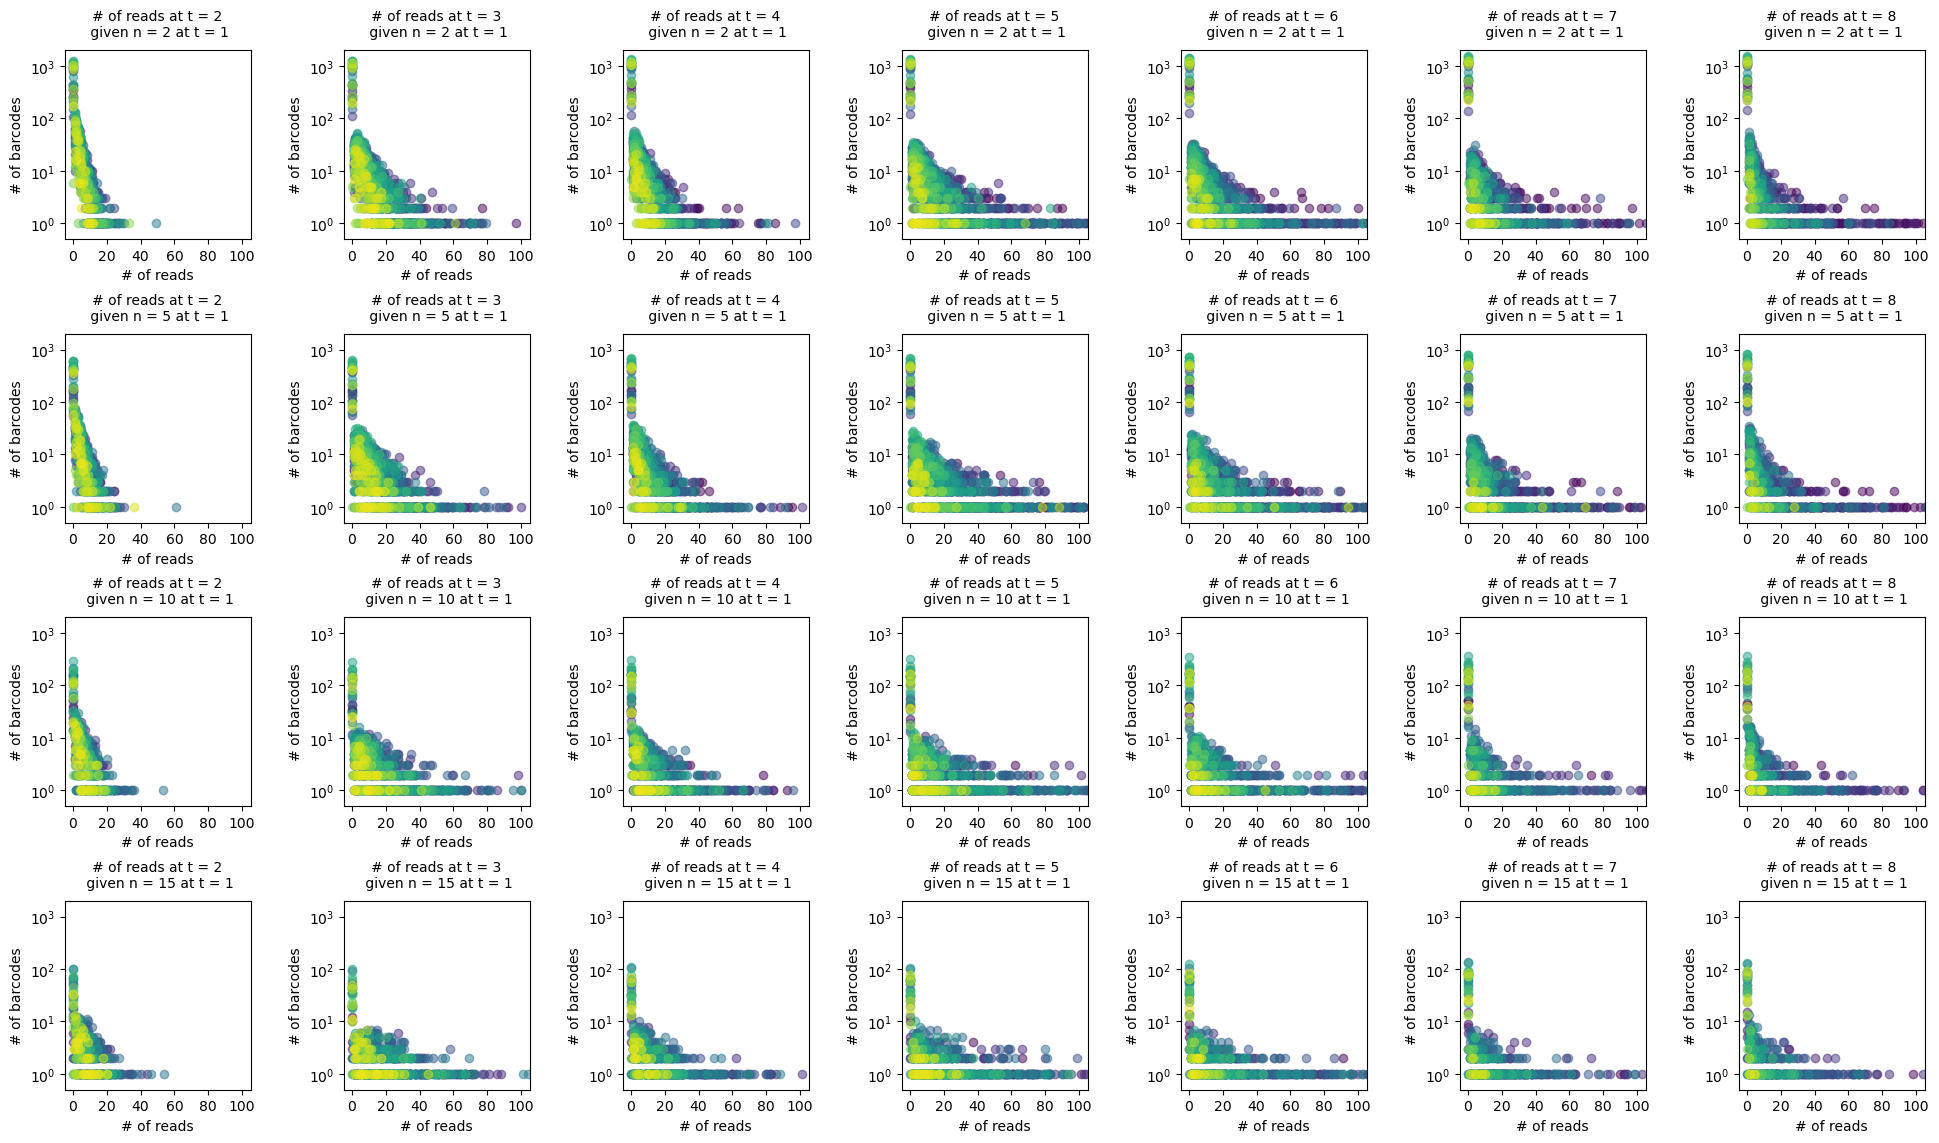

In [355]:
# now the last thing to do is Levy, Blundell plots: 
# want to find all barcodes at a given frequency at t = 1 and ask where are they later

plt.figure(figsize=(3 * 7 + 3, 3 * 4 + 1.5))
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))

grid = gridspec.GridSpec(ncols=7, nrows=4,
                         width_ratios=[1, 1, 1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1], hspace=0.5)


ns = [2, 5, 10, 15]
time_points = range(2, 9)
reps = 2

for i in range(28):
    
    plt.subplot(grid[i // 7, i % 7])
    
    n = ns[i // 7]
    time_point = time_points[i % 7]

    for count, clID in enumerate(clIDs_ordered):
        #if clID not in [clIDs_ordered[5]]:
        #    continue
        barcodes = [x for x in t_bc_counts[reps][clID].keys() if t_bc_counts[reps][clID][x][1] == n] # barcodes that are present at a given count at t=1
        n_reads = [t_bc_counts[reps][clID][x][time_point] for x in barcodes]
        n_reads_counts = [[x, n_reads.count(x)] for x in set(n_reads)]
    
        plt.scatter([x[0] for x in n_reads_counts], [x[1] for x in n_reads_counts], color=viridis.to_rgba(count), alpha=0.5, label=clID_dict[clID].replace('_', ' '))
        plt.yscale('log'); plt.minorticks_off();
    
        plt.xticks([0, 20, 40, 60, 80, 100], size=10)
        plt.xlim(-5, 105);

        plt.yticks([1e0, 1e1, 1e2, 1e3], [1e0, 1e1, 1e2, 1e3], size=10)
        plt.yscale('log'); plt.minorticks_off();
        plt.ylim(0.5, 2e3);

        plt.xlabel('# of reads', fontsize=10);
        plt.ylabel('# of barcodes', fontsize=10);

        plt.title(f"# of reads at t = {time_point}\n given n = {n} at t = 1", size=10, pad=10)

        #plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper left');
        
#plt.savefig('plots/levy_blundell_plot.png', dpi=300, bbox_inches='tight')     

